# 4.7 一次算整段時，答案該怎樣對齊？


有完整序列 `[1,2,3,4]` 時，希望模型在看到 1 後猜 2，看到 1、2 後猜 3，看到 1、2、3 後猜 4。與第一章同樣只移一格：輸入 `[1,2,3]`，答案 `[2,3,4]`。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

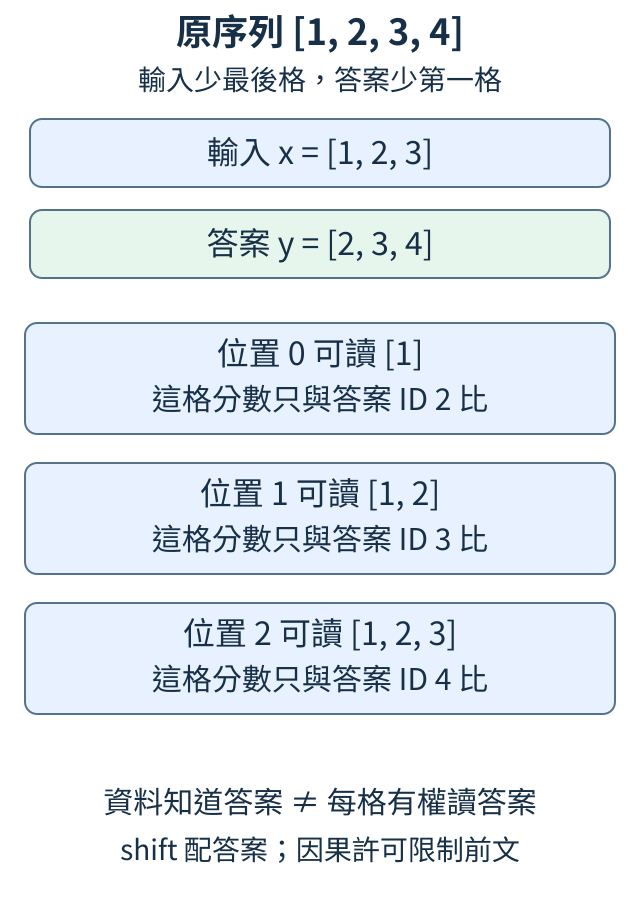

In [2]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-04-shift-causal.svg")))

圖中上方資料知道全部四格，下面每題的可讀前文卻受因果許可限制。訓練可同時算三題，是因為答案已經提供給評分；這不表示每題有權讀後面那格。生成不知道新答案，仍需逐字接長。


In [3]:
import torch
from tiny_perceptron.data import shifted
from tiny_perceptron.model import TinyLM, ModelConfig, masked_loss

torch.manual_seed(42)
x, y = shifted([1, 2, 3, 4])
model = TinyLM(ModelConfig(vocab_size=5, width=8))
logits = model(x[None])["logits"]
loss = masked_loss(logits, y[None])
print("問題答案", list(zip(x.tolist(), y.tolist())))
print("分數形狀", logits.shape, "平均代價", loss.item())
loss.backward()

問題答案 [(1, 2), (2, 3), (3, 4)]
分數形狀 torch.Size([1, 3, 5]) 平均代價 1.8268028497695923


`shifted` 回傳輸入 x 與答案 y，兩者各三格。`x[None]` 加筆數軸成為 `[1,3]`，模型得到 `[1,3,5]` 分數；字表五候選，合法 ID 是 0 到 4。

第一行印 `(1,2)、(2,3)、(3,4)`，指各輸入位置與答案；較後位置還能讀更早輸入。`masked_loss` 將同位置分數與 y 比，本例沒有忽略答案，所以取三題交叉熵平均。它不會再幫你 shift。

`loss.backward()` 只將答案代價對各參數的敏感度存起來，這次沒有 `step()` 或手動更新。模型尚未學會這段序列；示範目的是讓資料→模型→代價→梯度整條路接通。

若工具已 shift，模型內又 shift 一次，就會把「看 1 猜 2」改成「看 1 猜 3」。反過來把 `y=x.clone()`，長度仍吻合、程式仍能跑，卻改成複製目前字。先逐題讀對應，比看到 loss 是正數更有用。

練習延長原序列成 `[1,2,3,4,0]`，先手寫四對，再執行核對輸出 `[1,4,5]`。這時配對應為 `(1,2)、(2,3)、(3,4)、(4,0)`。

<details>
<summary>補充與重做</summary>

現有 [T.4](https://birdhackor.github.io/tiny-perceptron-vlm/training.html#T.4) 用 12 篇 `color=red;shape=circle;side=left.` 類短文，分 9／1／2 篇並實際更新。防偷看檢查將輸入 `[1,10,11,12,13]` 最後 ID 改成 14，比較前四位置全部候選分數，最大絕對差為 0.0；見 [原始報告](https://github.com/birdhackor/tiny-perceptron-vlm/blob/main/docs/course-experiments/results/text_foundation.json) 的 `results.causal_max_difference`。這項檢查確認改後格不影響前面，不能由單看 loss 下降取代。短機製程式與這個訓練實報是不同層次的證據。

</details>
